In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [4]:
max_features = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_len)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len)

print("Training samples:", len(x_train))

Training samples: 25000


In [5]:
def build_model(model_type):
    model = keras.Sequential()
    model.add(layers.Embedding(max_features, 128, input_length=max_len))

    if model_type == "RNN":
        model.add(layers.SimpleRNN(128))
    elif model_type == "LSTM":
        model.add(layers.LSTM(128))
    elif model_type == "GRU":
        model.add(layers.GRU(128))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [6]:
models = {}
histories = {}

for model_name in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {model_name}...")
    model = build_model(model_name)
    history = model.fit(x_train, y_train,
                        epochs=3,
                        batch_size=64,
                        validation_split=0.2,
                        verbose=1)
    models[model_name] = model
    histories[model_name] = history


Training RNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.5582 - loss: 0.6767 - val_accuracy: 0.6300 - val_loss: 0.6412
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7354 - loss: 0.5375 - val_accuracy: 0.7568 - val_loss: 0.5223
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8089 - loss: 0.4332 - val_accuracy: 0.7966 - val_loss: 0.4816

Training LSTM...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.7612 - loss: 0.4778 - val_accuracy: 0.8446 - val_loss: 0.3694
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8928 - loss: 0.2736 - val_accuracy: 0.8464 - val_loss: 0.3981
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9250 - loss: 0.2013 - val_accuracy: 0.8666 - val_loss: 0.3391

Training GRU...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7691 - loss: 0.4690 - val_accuracy: 0.8356 - val_loss: 0.3806
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.89

In [7]:
results = {}

for model_name, model in models.items():
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    results[model_name] = acc
    print(f"{model_name} Test Accuracy: {acc:.4f}")

RNN Test Accuracy: 0.7985
LSTM Test Accuracy: 0.8638
GRU Test Accuracy: 0.8573


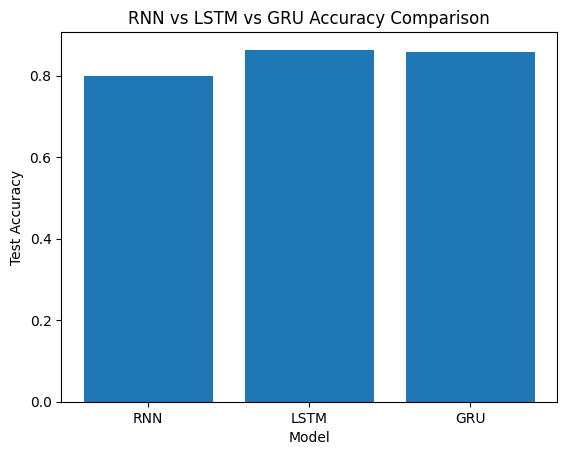

In [8]:
plt.figure()
plt.bar(results.keys(), results.values())
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("RNN vs LSTM vs GRU Accuracy Comparison")
plt.show()